<style>
.day4-card {background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}
.day4-card p,.day4-card li,.day4-card td {color:#111111 !important;}
.day4-card table {width:100%;border-collapse:collapse;}
.day4-card th {padding:9px;border:1px solid #CBD5E1;}
.day4-card td {padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}
</style>
<h1 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);text-align:center;font-weight:bold;padding:18px 12px;border-radius:10px;margin-bottom:7px;">Day 4 — Model Integration & Error Analysis</h1>
<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">Garbage Classification — From Raw Image to Prediction and Error Investigation</h3>
<div style="border-left:6px solid #FB7185;background-color:#FFF1F2;padding:12px 16px;margin:16px 0;border-radius:6px;color:#7F1D1D;"><b>Week 8 — AI & ML Internship • Day 4</b><br>Dataset folder: <code>garbage_classification/</code></div>
<div class="day4-card"><p><b>Main question:</b></p><div style="font-size:1.12em;font-weight:bold;text-align:center;background-color:#FFFBEB;border:1px solid #FBBF24;padding:16px;border-radius:8px;margin:14px 0;color:#111827;">Can one function take a raw garbage image, apply the exact training preprocessing, make a prediction, and help us understand when the model is wrong?</div></div>

<a id="toc"></a><h2 style="color:#92400E;background-color:#FBBF24;font-weight:bold;margin-top:30px;padding:9px 14px;border-radius:7px;">Table of Contents</h2>
<div style="border:1px solid #CBD5E1;padding:16px 25px;border-radius:8px;background-color:#FFFFFF;color:#111827;"><ul style="font-weight:bold;line-height:1.95;color:#1F2937;">
<li><a href="#section0">0. Setup — Imports & Dataset Path</a></li>
<li><a href="#section1">1. What Model Integration Means</a></li>
<li><a href="#section2">2. Load the Garbage Dataset</a></li>
<li><a href="#section3">3. Reuse Day 3 Preprocessing — One Source of Truth</a></li>
<li><a href="#section4">4. Build Image Features for the Model</a></li>
<li><a href="#section5">5. Train the Day 4 Baseline Model</a></li>
<li><a href="#section6">6. End-to-End predict() Pipeline</a></li>
<li><a href="#section7">7. Training / Serving Consistency</a></li>
<li><a href="#section8">8. Error Analysis</a></li>
<li><a href="#section9">9. Confusion Matrix</a></li>
<li><a href="#section10">10. Find the Most Common Error Type</a></li>
<li><a href="#section11">11. Inspect Misclassified Examples</a></li>
<li><a href="#section12">12. Review Three Errors</a></li>
<li><a href="#section13">13. What I Learned Today</a></li>
<li><a href="#section14">14. Day 4 Mental Map</a></li>
</ul></div>

<a id="section0"></a><h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">0. Setup — Imports & Dataset Path</h2>

<style>
.day4-card {background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}
.day4-card p,.day4-card li,.day4-card td {color:#111111 !important;}
.day4-card table {width:100%;border-collapse:collapse;}
.day4-card th {padding:9px;border:1px solid #CBD5E1;}
.day4-card td {padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}
</style><div class="day4-card"><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">0.1 Tools used</h3><p>This notebook uses <b>OpenCV, NumPy, pandas, scikit-learn, matplotlib</b>, and optionally <b>seaborn</b> for the confusion matrix.</p><div style="border-left:5px solid #FBBF24;background-color:#FFFBEB;padding:11px 15px;margin:12px 0;border-radius:5px;color:#78350F;"><b>Note:</b> Day 4 focuses on integration and error analysis. The shared <code>preprocessing.py</code> file keeps Day 3 and Day 4 preprocessing identical. A lightweight baseline is trained only because no saved trained classifier was provided.</div><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">0.2 Expected folder structure</h3><div style="background-color:#E0F2FE;color:#111827;padding:12px 14px;border-radius:8px;border:1px solid #CBD5E1;font-family:Consolas, 'Courier New', monospace;font-size:0.98em;font-weight:600;line-height:1.6;white-space:pre-wrap;margin:10px 0;">Week 8/
├── preprocessing.py       ← shared preprocessing
├── Day 3/
│   ├── Day3.ipynb
│   └── garbage_classification/
└── Day 4/
    └── Day4.ipynb</div></div>

In [1]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("OpenCV :", cv2.__version__)
print("NumPy  :", np.__version__)
print("pandas :", pd.__version__)

OpenCV : 5.0.0
NumPy  : 2.3.5
pandas : 2.3.3


In [2]:
candidate_roots = [
    Path("garbage_classification"),
    Path.cwd() / "garbage_classification",
    Path.cwd().parent / "Day 3" / "garbage_classification",
    Path("/mnt/data/garbage_classification"),
]

DATASET_ROOT = next((p for p in candidate_roots if p.exists() and p.is_dir()), None)

if DATASET_ROOT is None:
    nearby = []
    for base in [Path.cwd(), Path.cwd().parent]:
        if base.exists():
            nearby.extend([p for p in base.rglob("*") if p.is_dir() and "garbage" in p.name.lower()])
    DATASET_ROOT = nearby[0] if nearby else None

if DATASET_ROOT is None:
    raise FileNotFoundError(
        "Could not find the garbage_classification folder. Place it beside Day4.ipynb or keep it inside Day 3."
    )

print("Dataset root:", DATASET_ROOT.resolve())

Dataset root: C:\Users\sadee\OneDrive\Desktop\The Main Folder\The Main Folder\Week 8\Day 3\garbage_classification


<a id="section1"></a><h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">1. What Model Integration Means</h2>

<style>
.day4-card {background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}
.day4-card p,.day4-card li,.day4-card td {color:#111111 !important;}
.day4-card table {width:100%;border-collapse:collapse;}
.day4-card th {padding:9px;border:1px solid #CBD5E1;}
.day4-card td {padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}
</style><div class="day4-card"><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">1.1 From separate notebook cells to one coherent pipeline</h3><p>Model integration means combining preprocessing and prediction into one ordered workflow.</p><div style="background-color:#CCFBF1;color:#111827;padding:12px 14px;border-radius:8px;border:1px solid #CBD5E1;font-family:Consolas, 'Courier New', monospace;font-size:0.98em;font-weight:600;line-height:1.6;white-space:pre-wrap;margin:10px 0;">Before Integration
------------------
Cell 1 → Read Image
Cell 2 → Resize
Cell 3 → Convert Color
Cell 4 → Extract Features
Cell 5 → Model Prediction

After Integration
-----------------
Raw Image
   ↓
One predict() Function
   ↓
Prediction</div><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">1.2 The goal</h3><p>A raw input enters one side and a prediction comes out the other side, with every preprocessing step applied consistently in between.</p><div style="border-left:5px solid #FBBF24;background-color:#FFFBEB;padding:11px 15px;margin:12px 0;border-radius:5px;color:#78350F;"><b>Golden rule:</b> Prediction-time preprocessing must match training-time preprocessing.</div></div>

<a id="section2"></a><h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">2. Load the Garbage Dataset</h2>

<style>
.day4-card {background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}
.day4-card p,.day4-card li,.day4-card td {color:#111111 !important;}
.day4-card table {width:100%;border-collapse:collapse;}
.day4-card th {padding:9px;border:1px solid #CBD5E1;}
.day4-card td {padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}
</style><div class="day4-card"><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">2.1 Build a metadata table</h3><p>We index every image path and infer its class from the nearest meaningful parent folder.</p></div>

In [3]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
image_paths = sorted(p for p in DATASET_ROOT.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS)

if not image_paths:
    raise FileNotFoundError(f"No image files found inside: {DATASET_ROOT.resolve()}")

GENERIC_FOLDER_NAMES = {
    "train", "training", "test", "testing", "valid", "validation", "val",
    "images", "image", "data", "dataset", "garbage_classification", "garbage classification"
}

def infer_class_name(path):
    for parent in path.parents:
        if parent == DATASET_ROOT:
            break
        name = parent.name.strip()
        if name.lower() not in GENERIC_FOLDER_NAMES:
            return name
    return path.parent.name

image_df = pd.DataFrame({
    "path": [str(p) for p in image_paths],
    "class_name": [infer_class_name(p) for p in image_paths],
})

print("Images :", len(image_df))
print("Classes:", image_df["class_name"].nunique())
display(image_df.head())

Images : 15515
Classes: 12


,path,class_name
0,c:\Users\sadee\OneDrive\Desktop\The Main Folde...,battery
1,c:\Users\sadee\OneDrive\Desktop\The Main Folde...,battery
2,c:\Users\sadee\OneDrive\Desktop\The Main Folde...,battery
3,c:\Users\sadee\OneDrive\Desktop\The Main Folde...,battery
4,c:\Users\sadee\OneDrive\Desktop\The Main Folde...,battery


In [4]:
class_counts = image_df["class_name"].value_counts().sort_values(ascending=False)
display(class_counts.to_frame("image_count"))

,image_count
class_name,
clothes,5325
shoes,1977
paper,1050
biological,985
battery,945
cardboard,891
plastic,865
white-glass,775
metal,769


<style>
.day4-card {background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}
.day4-card p,.day4-card li,.day4-card td {color:#111111 !important;}
.day4-card table {width:100%;border-collapse:collapse;}
.day4-card th {padding:9px;border:1px solid #CBD5E1;}
.day4-card td {padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}
</style><div class="day4-card"><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">2.2 Keep the notebook practical</h3><p>Feature extraction from thousands of images can take time. The variable below lets the notebook use a reproducible sample while keeping classes represented.</p><div style="border-left:5px solid #FBBF24;background-color:#FFFBEB;padding:11px 15px;margin:12px 0;border-radius:5px;color:#78350F;"><b>Tip:</b> Set <code>MAX_IMAGES = None</code> if you want to use every image in the dataset.</div></div>

In [5]:
MAX_IMAGES = 6000  # Set to None to use the full dataset.

if MAX_IMAGES is not None and len(image_df) > MAX_IMAGES:
    sampled_parts = []
    per_class = max(1, MAX_IMAGES // image_df["class_name"].nunique())

    for class_name, group in image_df.groupby("class_name"):
        sampled_parts.append(group.sample(n=min(per_class, len(group)), random_state=SEED))

    work_df = pd.concat(sampled_parts, ignore_index=True)

    if len(work_df) > MAX_IMAGES:
        work_df = work_df.sample(n=MAX_IMAGES, random_state=SEED).reset_index(drop=True)
else:
    work_df = image_df.copy()

print("Images used in Day 4:", len(work_df))
print("Classes represented    :", work_df["class_name"].nunique())

Images used in Day 4: 6000
Classes represented    : 12


<a id="section3"></a><h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">3. Reuse Day 3 Preprocessing — One Source of Truth</h2>

<style>
.day4-card {background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}
.day4-card p,.day4-card li,.day4-card td {color:#111111 !important;}
.day4-card table {width:100%;border-collapse:collapse;}
.day4-card th {padding:9px;border:1px solid #CBD5E1;}
.day4-card td {padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}
</style><div class="day4-card"><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">3.1 Import the exact Day 3 preprocessing</h3>

<p>Day 4 should not contain a second copy of the preprocessing function. Instead, both days use the same shared <code>preprocessing.py</code> file.</p>

<div style="
    background-color:#CCFBF1;
    color:#111827;
    padding:12px 14px;
    border-radius:8px;
    border:1px solid #CBD5E1;
    font-family:Consolas, 'Courier New', monospace;
    font-size:0.98em;
    font-weight:600;
    line-height:1.6;
    white-space:pre-wrap;
    margin:10px 0;">Day 3
    ↓
preprocessing.py
    ↓
Day 4
    ↓
Same resize + same RGB conversion + same normalization</div>

<div style="
    border-left:5px solid #FBBF24;
    background-color:#FFFBEB;
    padding:11px 15px;
    margin:12px 0;
    border-radius:5px;
    color:#78350F;">
    <b>One Source of Truth:</b> If preprocessing changes later, it is changed once in <code>preprocessing.py</code>, not separately in multiple notebooks.
</div>
</div>

In [6]:
import sys
from pathlib import Path

# Find the shared preprocessing.py file.
preprocessing_locations = [
    Path.cwd(),
    Path.cwd().parent,
]

PREPROCESSING_ROOT = next(
    (
        location
        for location in preprocessing_locations
        if (location / "preprocessing.py").exists()
    ),
    None,
)

if PREPROCESSING_ROOT is None:
    raise FileNotFoundError(
        "Could not find preprocessing.py. "
        "Place it beside Day4.ipynb or in the parent Week 8 folder."
    )

if str(PREPROCESSING_ROOT) not in sys.path:
    sys.path.insert(0, str(PREPROCESSING_ROOT))

from preprocessing import preprocess_image, TARGET_SIZE


In [7]:
sample_path = work_df.iloc[0]["path"]
sample_image = preprocess_image(sample_path)
print("Shape :", sample_image.shape)
print("Dtype :", sample_image.dtype)
print("Range :", sample_image.min(), "to", sample_image.max())

Shape : (224, 224, 3)
Dtype : float32
Range : 0.0 to 1.0


<a id="section4"></a><h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">4. Build Image Features for the Model</h2>

<style>
.day4-card {background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}
.day4-card p,.day4-card li,.day4-card td {color:#111111 !important;}
.day4-card table {width:100%;border-collapse:collapse;}
.day4-card th {padding:9px;border:1px solid #CBD5E1;}
.day4-card td {padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}
</style><div class="day4-card"><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">4.1 Why use compact features here?</h3><p>The Day 4 goal is not to introduce a new deep-learning architecture. We need a trained model so we can practice integration, confusion matrices, and misclassification analysis.</p><p>For a lightweight baseline, each preprocessed image is converted into a compact numerical vector containing:</p><ul><li>RGB color histograms,</li><li>mean and standard deviation of each channel,</li><li>edge density.</li></ul><div style="background-color:#E0F2FE;color:#111827;padding:12px 14px;border-radius:8px;border:1px solid #CBD5E1;font-family:Consolas, 'Courier New', monospace;font-size:0.98em;font-weight:600;line-height:1.6;white-space:pre-wrap;margin:10px 0;">Preprocessed Image
      ↓
Compact Feature Vector
      ↓
Logistic Regression
      ↓
Garbage Class</div></div>

In [8]:
def extract_image_features(path):
    """Convert one raw image path into a compact numeric feature vector."""
    image_rgb = preprocess_image(path)
    features = []

    for channel in range(3):
        hist = cv2.calcHist(
            [(image_rgb[:, :, channel] * 255).astype("uint8")],
            [0], None, [16], [0, 256]
        ).flatten()
        hist = hist / (hist.sum() + 1e-8)
        features.extend(hist)

    for channel in range(3):
        channel_data = image_rgb[:, :, channel]
        features.append(float(channel_data.mean()))
        features.append(float(channel_data.std()))

    gray = cv2.cvtColor((image_rgb * 255).astype("uint8"), cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 100, 200)
    features.append(float((edges > 0).mean()))

    return np.asarray(features, dtype="float32")

In [9]:
sample_features = extract_image_features(sample_path)
print("Feature vector length:", len(sample_features))
print("First 10 values      :", np.round(sample_features[:10], 4))

Feature vector length: 55
First 10 values      : [0.007  0.0186 0.1089 0.079  0.0523 0.0659 0.0749 0.0604 0.0686 0.0999]


<style>
.day4-card {background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}
.day4-card p,.day4-card li,.day4-card td {color:#111111 !important;}
.day4-card table {width:100%;border-collapse:collapse;}
.day4-card th {padding:9px;border:1px solid #CBD5E1;}
.day4-card td {padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}
</style><div class="day4-card"><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">4.2 Create the training matrix</h3><p>This is the only step that may take some time because every selected image must be read once.</p></div>

In [10]:
X_features = []
valid_rows = []

for i, row in work_df.reset_index(drop=True).iterrows():
    try:
        X_features.append(extract_image_features(row["path"]))
        valid_rows.append(i)
    except Exception:
        pass

    if (i + 1) % 500 == 0:
        print(f"Processed {i + 1} / {len(work_df)} images")

model_df = work_df.reset_index(drop=True).iloc[valid_rows].reset_index(drop=True)
X = np.vstack(X_features)
y = model_df["class_name"].to_numpy()

print("\nFeature matrix:", X.shape)
print("Labels        :", y.shape)

Processed 500 / 6000 images
Processed 1000 / 6000 images
Processed 1500 / 6000 images
Processed 2000 / 6000 images
Processed 2500 / 6000 images
Processed 3000 / 6000 images
Processed 3500 / 6000 images
Processed 4000 / 6000 images
Processed 4500 / 6000 images
Processed 5000 / 6000 images
Processed 5500 / 6000 images
Processed 6000 / 6000 images

Feature matrix: (6000, 55)
Labels        : (6000,)


<a id="section5"></a><h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">5. Train the Day 4 Baseline Model</h2>

<style>
.day4-card {background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}
.day4-card p,.day4-card li,.day4-card td {color:#111111 !important;}
.day4-card table {width:100%;border-collapse:collapse;}
.day4-card th {padding:9px;border:1px solid #CBD5E1;}
.day4-card td {padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}
</style><div class="day4-card"><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">5.1 Train / test split</h3><p>The test set is kept separate so that error analysis reflects unseen examples.</p><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">5.2 scikit-learn Pipeline</h3><p>Feature scaling and the classifier are kept together in one scikit-learn pipeline.</p></div>

In [11]:
X_train, X_test, y_train, y_test, train_paths, test_paths = train_test_split(
    X, y, model_df["path"].to_numpy(),
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)
print("Training examples:", len(y_train))
print("Test examples    :", len(y_test))

Training examples: 4800
Test examples    : 1200


In [12]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1200,
        class_weight="balanced",
        random_state=SEED,
    )),
])
model.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


In [13]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy:.4f}")
print()
print(classification_report(y_test, y_pred, zero_division=0))

Test accuracy: 0.5133

              precision    recall  f1-score   support

     battery       0.49      0.62      0.55       100
  biological       0.57      0.51      0.54       100
 brown-glass       0.63      0.68      0.65       100
   cardboard       0.63      0.61      0.62       100
     clothes       0.44      0.59      0.50       100
 green-glass       0.71      0.79      0.75       100
       metal       0.50      0.30      0.38       100
       paper       0.47      0.59      0.52       100
     plastic       0.53      0.47      0.50       100
       shoes       0.29      0.09      0.14       100
       trash       0.43      0.66      0.52       100
 white-glass       0.34      0.25      0.29       100

    accuracy                           0.51      1200
   macro avg       0.50      0.51      0.50      1200
weighted avg       0.50      0.51      0.50      1200



<a id="section6"></a><h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">6. End-to-End predict() Pipeline</h2>

<style>
.day4-card {background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}
.day4-card p,.day4-card li,.day4-card td {color:#111111 !important;}
.day4-card table {width:100%;border-collapse:collapse;}
.day4-card th {padding:9px;border:1px solid #CBD5E1;}
.day4-card td {padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}
</style><div class="day4-card"><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">6.1 One raw input → one prediction</h3><p>This is the central integration step of Day 4.</p><div style="background-color:#CCFBF1;color:#111827;padding:12px 14px;border-radius:8px;border:1px solid #CBD5E1;font-family:Consolas, 'Courier New', monospace;font-size:0.98em;font-weight:600;line-height:1.6;white-space:pre-wrap;margin:10px 0;">Raw Image Path
      ↓
preprocess_image()
      ↓
extract_image_features()
      ↓
model.predict()
      ↓
Predicted Garbage Class</div></div>

In [14]:
def predict(raw_input, return_probabilities=False):
    """End-to-end prediction from a raw image path."""
    features = extract_image_features(raw_input).reshape(1, -1)
    prediction = model.predict(features)[0]
    result = {"prediction": prediction}

    if return_probabilities and hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(features)[0]
        classes = model.classes_
        result["probabilities"] = (
            pd.DataFrame({"class_name": classes, "probability": probabilities})
            .sort_values("probability", ascending=False)
            .reset_index(drop=True)
        )

    return result

In [15]:
example_path = test_paths[0]
result = predict(example_path, return_probabilities=True)
print("Image      :", example_path)
print("Prediction :", result["prediction"])
display(result["probabilities"].head())

Image      : c:\Users\sadee\OneDrive\Desktop\The Main Folder\The Main Folder\Week 8\Day 3\garbage_classification\biological\biological259.jpg
Prediction : biological


,class_name,probability
0,biological,0.705656
1,brown-glass,0.246648
2,green-glass,0.017538
3,metal,0.015304
4,shoes,0.009510


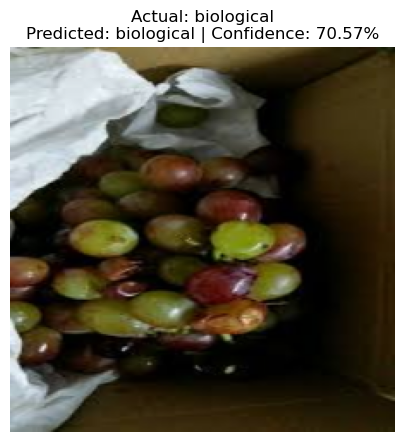

In [16]:
def show_prediction(path, actual=None):
    image = preprocess_image(path)
    result = predict(path, return_probabilities=True)
    predicted = result["prediction"]
    confidence = result["probabilities"].iloc[0]["probability"]

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")

    if actual is None:
        title = f"Predicted: {predicted} | Confidence: {confidence:.2%}"
    else:
        title = f"Actual: {actual}\nPredicted: {predicted} | Confidence: {confidence:.2%}"

    plt.title(title)
    plt.show()

show_prediction(example_path, actual=y_test[0])

<a id="section7"></a><h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">7. Training / Serving Consistency</h2>

<style>
.day4-card {background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}
.day4-card p,.day4-card li,.day4-card td {color:#111111 !important;}
.day4-card table {width:100%;border-collapse:collapse;}
.day4-card th {padding:9px;border:1px solid #CBD5E1;}
.day4-card td {padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}
</style><div class="day4-card"><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">7.1 What is training / serving skew?</h3><p>Training / serving skew happens when the model receives one preprocessing procedure during training and a different procedure during real prediction.</p><div style="background-color:#FFF7ED;color:#111827;padding:12px 14px;border-radius:8px;border:1px solid #CBD5E1;font-family:Consolas, 'Courier New', monospace;font-size:0.98em;font-weight:600;line-height:1.6;white-space:pre-wrap;margin:10px 0;">Training
Raw Image → Resize → RGB → Normalize → Features → Model

Prediction
Raw Image → Different Resize / BGR / Different Scaling → Model
                           ↑
                         SKEW</div><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">7.2 How this notebook prevents it</h3><p>Training and prediction both call the same <code>preprocess_image()</code> and <code>extract_image_features()</code> functions.</p></div>

In [17]:
features_for_training = extract_image_features(example_path)
features_for_prediction = extract_image_features(example_path)
consistent = np.allclose(features_for_training, features_for_prediction)
print("Training / prediction features identical:", consistent)

Training / prediction features identical: True


<style>
.day4-card {background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}
.day4-card p,.day4-card li,.day4-card td {color:#111111 !important;}
.day4-card table {width:100%;border-collapse:collapse;}
.day4-card th {padding:9px;border:1px solid #CBD5E1;}
.day4-card td {padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}
</style><div class="day4-card"><div style="border-left:5px solid #FBBF24;background-color:#FFFBEB;padding:11px 15px;margin:12px 0;border-radius:5px;color:#78350F;"><b>Golden rule:</b> The safest preprocessing code is code that exists in one place and is reused everywhere.</div></div>

<a id="section8"></a><h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">8. Error Analysis</h2>

<style>
.day4-card {background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}
.day4-card p,.day4-card li,.day4-card td {color:#111111 !important;}
.day4-card table {width:100%;border-collapse:collapse;}
.day4-card th {padding:9px;border:1px solid #CBD5E1;}
.day4-card td {padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}
</style><div class="day4-card"><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">8.1 Accuracy is not enough</h3><p>A single accuracy value tells us how often the model is correct, but it does not show <b>where</b> the model fails.</p><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">8.2 Professional error analysis asks</h3><ul><li>Which classes are confused with each other?</li><li>Does one class fail more than others?</li><li>Are the mistakes visually understandable?</li><li>Is the problem caused by the data or by the model?</li></ul><div style="background-color:#CCFBF1;color:#111827;padding:12px 14px;border-radius:8px;border:1px solid #CBD5E1;font-family:Consolas, 'Courier New', monospace;font-size:0.98em;font-weight:600;line-height:1.6;white-space:pre-wrap;margin:10px 0;">Accuracy
   ↓
Confusion Matrix
   ↓
Most Common Error Pair
   ↓
Inspect Wrong Predictions
   ↓
Data Issue OR Model Weakness</div></div>

In [18]:
results_df = pd.DataFrame({"path": test_paths, "actual": y_test, "predicted": y_pred})
results_df["correct"] = results_df["actual"] == results_df["predicted"]
print("Correct predictions   :", results_df["correct"].sum())
print("Incorrect predictions :", (~results_df["correct"]).sum())
print("Test accuracy         :", f"{accuracy:.2%}")

Correct predictions   : 616
Incorrect predictions : 584
Test accuracy         : 51.33%


<a id="section9"></a><h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">9. Confusion Matrix</h2>

<style>
.day4-card {background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}
.day4-card p,.day4-card li,.day4-card td {color:#111111 !important;}
.day4-card table {width:100%;border-collapse:collapse;}
.day4-card th {padding:9px;border:1px solid #CBD5E1;}
.day4-card td {padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}
</style><div class="day4-card"><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">9.1 Actual class vs. predicted class</h3><p>The confusion matrix shows exactly which classes the model confuses.</p></div>

In [19]:
labels = np.sort(np.unique(y_test))
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
display(cm_df)

,battery,biological,brown-glass,cardboard,clothes,green-glass,metal,paper,plastic,shoes,trash,white-glass
battery,62,5,1,3,6,8,4,2,2,0,6,1
biological,4,51,13,5,8,4,1,6,0,6,0,2
brown-glass,5,6,68,2,1,2,5,5,1,4,0,1
cardboard,1,7,6,61,8,0,4,3,3,1,1,5
clothes,1,6,0,6,59,3,3,12,0,6,1,3
green-glass,1,4,5,4,0,79,3,2,1,0,0,1
metal,7,2,7,3,5,6,30,7,9,2,13,9
paper,1,3,1,2,10,2,2,59,9,2,0,9
plastic,7,1,1,3,6,4,4,4,47,0,20,3
shoes,32,4,5,3,26,2,1,11,1,9,5,1


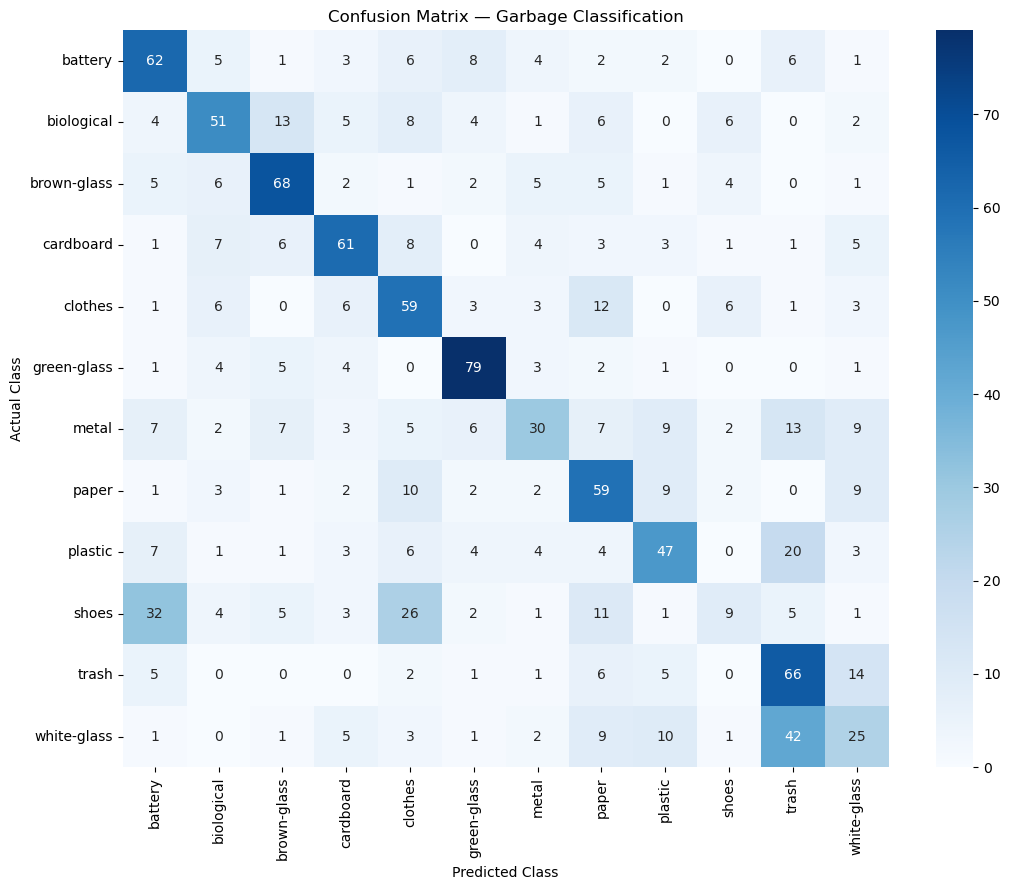

In [20]:
plt.figure(figsize=(11, 9))

try:
    import seaborn as sns
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
except ModuleNotFoundError:
    plt.imshow(cm, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(labels)), labels, rotation=90)
    plt.yticks(range(len(labels)), labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

plt.title("Confusion Matrix — Garbage Classification")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

<a id="section10"></a><h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">10. Find the Most Common Error Type</h2>

<style>
.day4-card {background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}
.day4-card p,.day4-card li,.day4-card td {color:#111111 !important;}
.day4-card table {width:100%;border-collapse:collapse;}
.day4-card th {padding:9px;border:1px solid #CBD5E1;}
.day4-card td {padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}
</style><div class="day4-card"><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">10.1 Which pair is confused most often?</h3><p>We remove correct predictions and count the remaining actual → predicted pairs.</p></div>

In [21]:
errors_df = results_df.loc[~results_df["correct"]].copy()

if len(errors_df) == 0:
    print("No misclassified examples in this test split.")
else:
    error_pairs = (
        errors_df.groupby(["actual", "predicted"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
    )
    display(error_pairs.head(10))

,actual,predicted,count
0,white-glass,trash,42
1,shoes,battery,32
2,shoes,clothes,26
3,plastic,trash,20
4,trash,white-glass,14
5,biological,brown-glass,13
6,metal,trash,13
7,clothes,paper,12
8,shoes,paper,11
9,paper,clothes,10


In [22]:
if len(errors_df) > 0:
    top_error = error_pairs.iloc[0]
    print("Most common error:")
    print(f"{top_error['actual']} → {top_error['predicted']} ({top_error['count']} examples)")

Most common error:
white-glass → trash (42 examples)


<a id="section11"></a><h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">11. Inspect Misclassified Examples</h2>

<style>
.day4-card {background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}
.day4-card p,.day4-card li,.day4-card td {color:#111111 !important;}
.day4-card table {width:100%;border-collapse:collapse;}
.day4-card th {padding:9px;border:1px solid #CBD5E1;}
.day4-card td {padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}
</style><div class="day4-card"><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">11.1 Why inspect the actual mistakes?</h3><p>A confusion matrix reveals patterns, but the images explain those patterns.</p><p>A wrong prediction may be:</p><ul><li><b>Genuinely ambiguous</b> — two classes look visually similar.</li><li><b>A data-quality issue</b> — poor lighting, crop, label, or unusual image.</li><li><b>A model weakness</b> — the image is clear but the model still fails.</li></ul><div style="border-left:5px solid #FBBF24;background-color:#FFFBEB;padding:11px 15px;margin:12px 0;border-radius:5px;color:#78350F;"><b>This qualitative step is important:</b> do not stop at the accuracy score or confusion matrix.</div></div>

In [23]:
def prediction_confidence(path):
    result = predict(path, return_probabilities=True)
    return float(result["probabilities"].iloc[0]["probability"])

if len(errors_df) > 0:
    errors_df["confidence"] = [prediction_confidence(path) for path in errors_df["path"]]
    display(errors_df.sort_values("confidence", ascending=False).head(10))

,path,actual,predicted,correct,confidence
157,c:\Users\sadee\OneDrive\Desktop\The Main Folde...,plastic,green-glass,False,0.997604
673,c:\Users\sadee\OneDrive\Desktop\The Main Folde...,metal,green-glass,False,0.997598
170,c:\Users\sadee\OneDrive\Desktop\The Main Folde...,shoes,green-glass,False,0.997322
532,c:\Users\sadee\OneDrive\Desktop\The Main Folde...,cardboard,biological,False,0.994757
26,c:\Users\sadee\OneDrive\Desktop\The Main Folde...,white-glass,paper,False,0.982660
297,c:\Users\sadee\OneDrive\Desktop\The Main Folde...,plastic,biological,False,0.982395
614,c:\Users\sadee\OneDrive\Desktop\The Main Folde...,battery,green-glass,False,0.972339
650,c:\Users\sadee\OneDrive\Desktop\The Main Folde...,shoes,brown-glass,False,0.970462
634,c:\Users\sadee\OneDrive\Desktop\The Main Folde...,clothes,paper,False,0.961394
687,c:\Users\sadee\OneDrive\Desktop\The Main Folde...,green-glass,biological,False,0.961110


In [24]:
def add_label_to_rgb(image_rgb, label):
    canvas = image_rgb.copy()
    cv2.rectangle(canvas, (0, 0), (canvas.shape[1], 38), (255, 255, 255), -1)
    cv2.putText(canvas, str(label)[:42], (6, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.48, (20, 20, 20), 1, cv2.LINE_AA)
    return canvas

def make_montage(images_rgb, labels, columns=3, tile_size=(220, 220)):
    tiles = []
    for image, label in zip(images_rgb, labels):
        tile = cv2.resize(image, tile_size)
        tiles.append(add_label_to_rgb(tile, label))

    rows = []
    for start in range(0, len(tiles), columns):
        row_tiles = tiles[start:start + columns]
        while len(row_tiles) < columns:
            row_tiles.append(np.full_like(tiles[0], 255))
        rows.append(np.hstack(row_tiles))

    return np.vstack(rows)

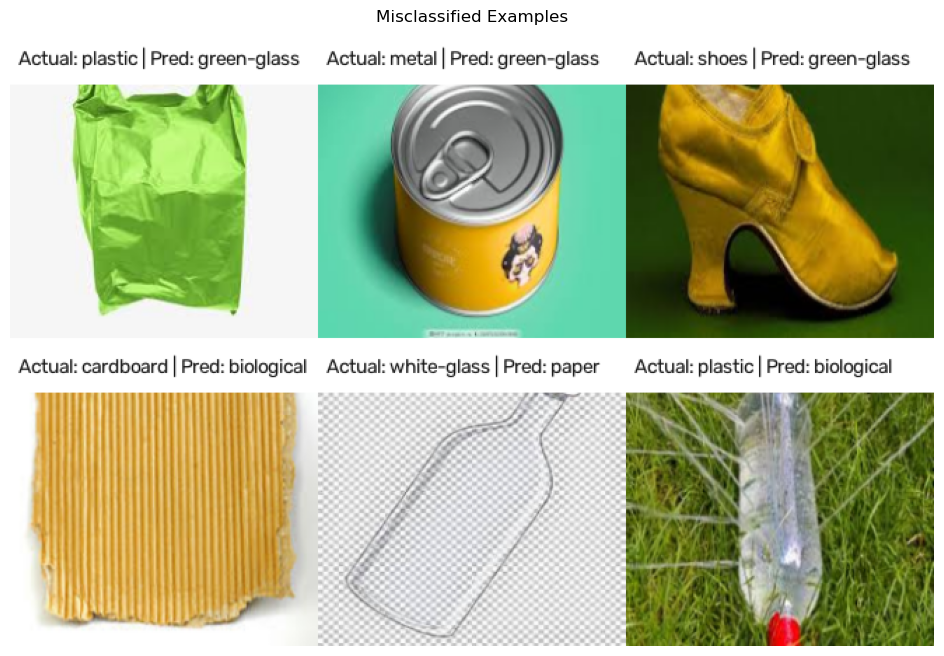

In [25]:
if len(errors_df) > 0:
    inspect_df = errors_df.sort_values("confidence", ascending=False).head(min(6, len(errors_df))).copy()
    inspect_images = []
    inspect_labels = []

    for _, row in inspect_df.iterrows():
        image = preprocess_image(row["path"])
        image_uint8 = np.clip(image * 255, 0, 255).astype("uint8")
        inspect_images.append(image_uint8)
        inspect_labels.append(f"Actual: {row['actual']} | Pred: {row['predicted']}")

    montage = make_montage(inspect_images, inspect_labels, columns=3)
    plt.figure(figsize=(12, 8))
    plt.imshow(montage)
    plt.axis("off")
    plt.title("Misclassified Examples")
    plt.show()

<a id="section12"></a><h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">12. Review Three Errors</h2>

<style>
.day4-card {background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}
.day4-card p,.day4-card li,.day4-card td {color:#111111 !important;}
.day4-card table {width:100%;border-collapse:collapse;}
.day4-card th {padding:9px;border:1px solid #CBD5E1;}
.day4-card td {padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}
</style><div class="day4-card"><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">12.1 Human review is part of the lab</h3><p>The model can show us what it got wrong, but deciding whether an error is a <b>Data Issue</b> or a <b>Model Weakness</b> requires looking at the actual image.</p><table><tr style="background-color:#0F766E;color:white;"><th style="color:white;">Category</th><th style="color:white;">Use when...</th></tr><tr><td><b>Data Issue</b></td><td>The image is badly cropped, mislabeled, unusually dark, ambiguous, or otherwise problematic.</td></tr><tr><td><b>Model Weakness</b></td><td>The image is reasonably clear, but the model still confuses it with another class.</td></tr></table><div style="border-left:5px solid #FBBF24;background-color:#FFFBEB;padding:11px 15px;margin:12px 0;border-radius:5px;color:#78350F;"><b>Do not auto-label these categories.</b> This is intentionally a qualitative human-review step.</div></div>

In [26]:
if len(errors_df) > 0:
    review_df = (
        errors_df.sort_values("confidence", ascending=False)
        .head(min(3, len(errors_df)))[["path", "actual", "predicted", "confidence"]]
        .copy()
    )
    review_df["review_category"] = ""
    review_df["notes"] = ""
    display(review_df)
else:
    print("There are no errors to review in this test split.")

,path,actual,predicted,confidence,review_category,notes
157,c:\Users\sadee\OneDrive\Desktop\The Main Folde...,plastic,green-glass,0.997604,,
673,c:\Users\sadee\OneDrive\Desktop\The Main Folde...,metal,green-glass,0.997598,,
170,c:\Users\sadee\OneDrive\Desktop\The Main Folde...,shoes,green-glass,0.997322,,


<style>
.day4-card {background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}
.day4-card p,.day4-card li,.day4-card td {color:#111111 !important;}
.day4-card table {width:100%;border-collapse:collapse;}
.day4-card th {padding:9px;border:1px solid #CBD5E1;}
.day4-card td {padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}
</style><div class="day4-card"><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">12.2 Fill the final two columns after viewing the images</h3><p>For each of the three examples, write:</p><ul><li><b>review_category:</b> <code>Data Issue</code> or <code>Model Weakness</code></li><li><b>notes:</b> a short explanation of why you chose that category</li></ul><div style="background-color:#FFF7ED;color:#111827;padding:12px 14px;border-radius:8px;border:1px solid #CBD5E1;font-family:Consolas, 'Courier New', monospace;font-size:0.98em;font-weight:600;line-height:1.6;white-space:pre-wrap;margin:10px 0;">Example:
Actual: cardboard
Predicted: paper
Review category: Model Weakness
Notes: The object is clear, but paper and cardboard share similar color and texture.</div></div>

<a id="section13"></a><h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">13. What I Learned Today</h2>

<style>
.day4-card {background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}
.day4-card p,.day4-card li,.day4-card td {color:#111111 !important;}
.day4-card table {width:100%;border-collapse:collapse;}
.day4-card th {padding:9px;border:1px solid #CBD5E1;}
.day4-card td {padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}
</style><div class="day4-card"><ul>
<li><b>Model Integration:</b> How to combine preprocessing and prediction into one coherent workflow.</li>
<li><b>End-to-End Pipeline:</b> How one raw image can move through preprocessing, feature extraction, and prediction automatically.</li>
<li><b>predict() Function:</b> How to expose one simple interface for inference.</li>
<li><b>Training / Serving Consistency:</b> Why training-time and prediction-time preprocessing must match.</li>
<li><b>Training / Serving Skew:</b> How inconsistent preprocessing can silently damage predictions.</li>
<li><b>Error Analysis:</b> Why accuracy alone is not enough to understand model behavior.</li>
<li><b>Confusion Matrix:</b> How to identify which classes are confused with each other.</li>
<li><b>Most Common Error Type:</b> How to count the most frequent actual → predicted mistake.</li>
<li><b>Misclassified Examples:</b> How to inspect wrong predictions instead of relying only on metrics.</li>
<li><b>Data Issue vs. Model Weakness:</b> How to categorize model errors through qualitative review.</li>
</ul></div>

<a id="section14"></a><h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">14. Day 4 Mental Map</h2>

<style>
.day4-card {background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}
.day4-card p,.day4-card li,.day4-card td {color:#111111 !important;}
.day4-card table {width:100%;border-collapse:collapse;}
.day4-card th {padding:9px;border:1px solid #CBD5E1;}
.day4-card td {padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}
</style><div class="day4-card"><div style="background-color:#CCFBF1;color:#111827;padding:12px 14px;border-radius:8px;border:1px solid #CBD5E1;font-family:Consolas, 'Courier New', monospace;font-size:0.98em;font-weight:600;line-height:1.6;white-space:pre-wrap;margin:10px 0;">RAW GARBAGE IMAGE
        ↓
ONE SOURCE OF TRUTH
preprocessing.py
preprocess_image()
        ↓
extract_image_features()
        ↓
TRAINED MODEL
        ↓
predict()
        ↓
PREDICTED CLASS
        ↓
┌─────────────────────────────┐
│      ERROR ANALYSIS         │
├─────────────────────────────┤
│ Accuracy                    │
│ Confusion Matrix            │
│ Most Common Error Pair      │
│ Misclassified Examples      │
│ Data Issue / Model Weakness │
└─────────────────────────────┘</div><div style="border-left:5px solid #FBBF24;background-color:#FFFBEB;padding:11px 15px;margin:12px 0;border-radius:5px;color:#78350F;"><b>Day 4 in one sentence:</b> Integrate the pipeline, keep preprocessing consistent, then study the model's mistakes instead of looking only at accuracy.</div></div>